# 02b (YM) — Event Response in the E-mini Dow: Is CPI Also the Valuable Release There?

## Purpose

Notebooks 01–02 established, **for ES**, that CPI is the macro release whose surprise strongly and reliably
moves the market, and Notebook 02b (NQ, ZN) repeated that study for the Nasdaq-100 and the 10-year note.
This notebook repeats the **same Notebook 02 event study for YM (E-mini Dow)**, with ES and NQ as references,
to answer:

> **Does YM react to CPI, NFP and PCE surprises like ES, and does part of the reaction remain after the first
> minute, where it can be traded?**

Code, horizons and regressions are identical to Notebook 02b; only the market list changes (ES, NQ, YM).
YM prices come from `futures_1min_clean_v3_YM.parquet`, written by `combined/cleaning.py` in the team repo
after `combined/pull.py --pull YM`. Outputs are saved as `nb02b_YM_*`, so nothing from Notebook 02b is
overwritten.


## 1. Setup

In [1]:
from pathlib import Path
import sys, importlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"
TEAM_DATA = PROJECT_ROOT.parent / "blackrock-intraday" / "data" / "processed"
EVENT_FILE = PROCESSED_DIR / "macro_event_model_data_2016_2026.parquet"     # Notebook 02 output
MARKETS = {
    "ES": (RAW_DIR / "ES_1m_2010_2026_full.parquet", "project"),
    "NQ": (TEAM_DATA / "futures_1min_clean_v3_NQ.parquet", "team_v3"),
    "YM": (TEAM_DATA / "futures_1min_clean_v3_YM.parquet", "team_v3"),   # E-mini Dow, from combined/cleaning.py
}

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import src.state_conditioning as sc
import src.multi_asset as ma
for m in (sc, ma):
    importlib.reload(m)

print("Event file:", EVENT_FILE.exists())
for s, (f, _) in MARKETS.items():
    print(f"{s}: {f.exists()}")

HORIZONS = [1, 5, 15, 30, 60]
DRIFT_HORIZONS = [5, 15, 30, 60]
FAMILY_VARS = {                       # the Notebook 02 regression specification
    "CPI": ["headline_cpi", "core_cpi"],
    "NFP": ["nonfarm_payrolls", "unemployment_rate", "avg_hourly_earnings"],
    "PCE": ["headline_pce", "core_pce"],
}
SPLIT = "2021-01-01"                  # stability check: 2016-2020 vs 2021-2026

Event file: True
ES: True
NQ: True
YM: True


## 2. Load the Notebook 02 Event Dataset

In [2]:
ev = pd.read_parquet(EVENT_FILE)
ev["timestamp_utc"] = pd.to_datetime(ev["timestamp_utc"], utc=True)
ev = ev.sort_values("timestamp_utc").reset_index(drop=True)
print("Events:", len(ev), "|", ev["timestamp_utc"].min().date(), "to", ev["timestamp_utc"].max().date())
display(ev["event_type"].value_counts().to_frame("n"))

Events: 363 | 2016-01-08 to 2026-06-25


,n
event_type,
NFP,122
CPI,122
PCE,119


## 3. Returns for ES, NQ and YM at Every Release

Prices are the close of each 1-minute bar (bars labelled by their start minute, as in Notebook 02), roll-adjusted within each market. For release time $T$:
- reaction over $h$ minutes: close of bar $T+h-1$ vs close of bar $T-1$
- drift over $h$ minutes: close of bar $T+h-1$ vs close of bar $T$ (entry about 1 minute after the release)

In [3]:
def returns_at(adj, ts):
    idx = adj.index.as_unit("ns") if hasattr(adj.index, "as_unit") else adj.index
    t_ns = idx.asi8
    lp = adj["logp_adj"].to_numpy()
    T = pd.DatetimeIndex(ts)
    T = T.as_unit("ns") if hasattr(T, "as_unit") else T
    def at(label):
        x = T.asi8 + label * 60 * 10**9
        pos = np.searchsorted(t_ns, x, side="right") - 1
        ok = (pos >= 0) & ((x - t_ns[np.clip(pos, 0, None)]) <= 5 * 60 * 10**9)
        return np.where(ok, lp[np.clip(pos, 0, None)], np.nan)
    pre, p0 = at(-1), at(0)
    out = pd.DataFrame(index=T)
    for h in HORIZONS:
        out[f"ret_{h}m"] = (at(h - 1) - pre) * 1e4
    for h in DRIFT_HORIZONS:
        out[f"drift_{h}m"] = (at(h - 1) - p0) * 1e4
    return out

R = {}
for sym, (path, kind) in MARKETS.items():
    adj = ma.adjusted(ma.load_bars(path, kind))
    R[sym] = returns_at(adj, ev["timestamp_utc"])
    print(f"{sym}: releases with a complete 60-minute reaction: {R[sym]['ret_60m'].notna().sum()} / {len(ev)}")

# validation: ES must reproduce the Notebook 02 returns
gaps = {h: float(np.nanmax(np.abs(R['ES'][f'ret_{h}m'].to_numpy() - ev[f'ret_{h}m_bps'].to_numpy()))) for h in HORIZONS}
print("\nMax |ES here - Notebook 02| by horizon (bps):", {h: f"{g:.1e}" for h, g in gaps.items()})
print("(small differences can only come from contract rolls inside a window; Notebook 02 used unadjusted prices)")

ES: releases with a complete 60-minute reaction: 363 / 363
NQ: releases with a complete 60-minute reaction: 354 / 363
YM: releases with a complete 60-minute reaction: 348 / 363

Max |ES here - Notebook 02| by horizon (bps): {1: '3.4e-11', 5: '3.4e-11', 15: '3.5e-11', 30: '3.4e-11', 60: '3.4e-11'}
(small differences can only come from contract rolls inside a window; Notebook 02 used unadjusted prices)


## 4. Market Impact: How Much Does Each Release Move Each Market?

In [4]:
rows = []
for sym in MARKETS:
    d = pd.concat([ev[["event_type"]], R[sym].reset_index(drop=True)], axis=1)
    for fam_, g in d.groupby("event_type"):
        rows.append({"market": sym, "release": fam_, **{f"|{h}m|": g[f"ret_{h}m"].abs().mean() for h in HORIZONS}})
impact = pd.DataFrame(rows).set_index(["market", "release"])
impact.to_csv(RESULTS_DIR / "nb02b_YM_market_impact.csv")
print("Mean absolute reaction (bps) by market and release:")
display(impact.round(1))

# relative impact: each release vs the market's average release (removes the fact that ZN moves less than ES)
rel = impact["|30m|"].unstack("release")
rel = rel.div(rel.mean(axis=1), axis=0)
print("\nRelative 30-minute impact (1.00 = the market's average across CPI, NFP, PCE):")
display(rel.round(2))

Mean absolute reaction (bps) by market and release:


|1m|   |5m|  |15m|  |30m|  |60m|
market release                                   
ES     CPI     28.100 31.400 34.600 38.500 37.800
       NFP     21.500 26.300 26.100 29.600 29.200
       PCE      7.000  9.400 12.900 14.900 18.100
NQ     CPI     38.600 44.700 48.400 53.600 54.000
       NFP     25.600 31.600 31.500 36.000 35.100
       PCE      9.200 12.500 17.200 18.500 23.200
YM     CPI     23.700 27.700 29.600 33.200 33.300
       NFP     19.300 23.700 25.000 27.900 28.600
       PCE      5.400  7.300 10.200 11.900 15.900


Relative 30-minute impact (1.00 = the market's average across CPI, NFP, PCE):


release,CPI,NFP,PCE
market,,,
ES,1.390,1.070,0.540
NQ,1.490,1.000,0.510
YM,1.370,1.150,0.490


## 5. Reaction Regressions (Notebook 02 Specification)

For each market, release and horizon: $R_{T,h} = \alpha + \sum_k \beta_k\, z_k + \varepsilon$ with the release's surprise components, and HC3 robust standard errors. $\beta$ is in **bps per 1-SD surprise**.

In [5]:
def regress(y, X):
    d = pd.concat([y.rename("y"), X], axis=1).dropna()
    if len(d) < 20:
        return None
    r = sc.ols_hc3(d["y"], pd.concat([pd.Series(1.0, index=d.index, name="const"), d[X.columns]], axis=1))
    return r

def run_regs(kind, horizons, sample=None):
    rows = []
    for sym in MARKETS:
        d = pd.concat([ev, R[sym].reset_index(drop=True)], axis=1)
        if sample is not None:
            d = d[sample(d)]
        for fam_, vars_ in FAMILY_VARS.items():
            g = d[d["event_type"] == fam_]
            for h in horizons:
                r = regress(g[f"{kind}_{h}m"], g[vars_])
                if r is None:
                    continue
                for v in vars_:
                    rows.append(dict(market=sym, release=fam_, horizon=h, variable=v, n=r.n,
                                     beta=r.params[v], t=r.t[v], p=r.p[v], r2=r.r2))
    return pd.DataFrame(rows)

react = run_regs("ret", HORIZONS)
react.to_csv(RESULTS_DIR / "nb02b_YM_reaction_regressions.csv", index=False)

r2 = react.drop_duplicates(["market", "release", "horizon"]).pivot_table(index=["release", "horizon"], columns="market", values="r2")
print("R² of the reaction regression (share of the move explained by the surprise):")
display(r2[list(MARKETS)].round(3))

R² of the reaction regression (share of the move explained by the surprise):


market             ES    NQ    YM
release horizon                  
CPI     1       0.299 0.323 0.284
        5       0.273 0.296 0.266
        15      0.223 0.261 0.198
        30      0.252 0.290 0.227
        60      0.231 0.271 0.213
NFP     1       0.028 0.012 0.047
        5       0.034 0.013 0.066
        15      0.050 0.006 0.126
        30      0.041 0.003 0.096
        60      0.070 0.011 0.138
PCE     1       0.138 0.169 0.093
        5       0.096 0.102 0.094
        15      0.058 0.052 0.062
        30      0.026 0.034 0.048
        60      0.032 0.039 0.069

In [6]:
key_vars = ["headline_cpi", "core_cpi", "nonfarm_payrolls", "unemployment_rate", "avg_hourly_earnings", "headline_pce", "core_pce"]
for h in [5, 30]:
    t = react[react.horizon == h].pivot_table(index="variable", columns="market", values=["beta", "t"]).reindex(key_vars)
    t.columns = [f"{m} {s}" for s, m in t.columns]
    print(f"\nReaction over {h} minutes: beta (bps per 1-SD surprise) and t-stat")
    display(t[[f"{m} {s}" for m in MARKETS for s in ["beta", "t"]]].round(2))


Reaction over 5 minutes: beta (bps per 1-SD surprise) and t-stat


,ES beta,ES t,NQ beta,NQ t,YM beta,YM t
variable,,,,,,
headline_cpi,-20.760,-2.830,-27.740,-2.720,-19.190,-2.830
core_cpi,-6.410,-1.080,-9.710,-1.180,-3.250,-0.610
nonfarm_payrolls,2.770,1.050,2.480,0.980,2.800,1.060
unemployment_rate,4.260,1.150,4.820,1.340,3.670,0.970
avg_hourly_earnings,-0.970,-0.060,-0.900,-0.050,-0.930,-0.070
headline_pce,-3.820,-1.780,-5.210,-1.990,-2.940,-1.650
core_pce,-0.780,-0.450,-1.010,-0.430,-0.760,-0.570



Reaction over 30 minutes: beta (bps per 1-SD surprise) and t-stat


,ES beta,ES t,NQ beta,NQ t,YM beta,YM t
variable,,,,,,
headline_cpi,-23.770,-2.650,-30.480,-2.550,-20.920,-2.540
core_cpi,-7.080,-0.910,-12.810,-1.250,-3.200,-0.450
nonfarm_payrolls,2.530,0.980,1.260,0.430,2.890,1.020
unemployment_rate,2.650,0.640,2.290,0.520,2.310,0.540
avg_hourly_earnings,-0.730,-0.060,-0.490,-0.040,-0.780,-0.080
headline_pce,-3.260,-1.460,-4.200,-1.370,-2.930,-1.760
core_pce,-0.690,-0.240,-1.380,-0.360,-1.390,-0.560


**How to read it.** Compare the **R²** and the **t-stats** across markets. If CPI is the dominant release in every market, its R² should be clearly higher than NFP's and PCE's in NQ and ZN too. For ZN, expect **negative** betas on inflation and on strong jobs data (bond prices fall when yields rise).

## 6. Tradeable Drift Regressions (after the first minute)

In [7]:
drift = run_regs("drift", DRIFT_HORIZONS)
drift.to_csv(RESULTS_DIR / "nb02b_YM_drift_regressions.csv", index=False)
d30 = drift[drift.horizon == 30].pivot_table(index="variable", columns="market", values=["beta", "t"]).reindex(key_vars)
d30.columns = [f"{m} {s}" for s, m in d30.columns]
print("Tradeable drift T+1 -> T+30: beta (bps per 1-SD surprise) and t-stat")
display(d30[[f"{m} {s}" for m in MARKETS for s in ["beta", "t"]]].round(2))

r2d = drift.drop_duplicates(["market", "release", "horizon"]).pivot_table(index=["release", "horizon"], columns="market", values="r2")
print("\nR² of the drift regression:")
display(r2d[list(MARKETS)].round(3))

Tradeable drift T+1 -> T+30: beta (bps per 1-SD surprise) and t-stat


,ES beta,ES t,NQ beta,NQ t,YM beta,YM t
variable,,,,,,
headline_cpi,-5.670,-1.370,-4.590,-0.900,-5.280,-1.370
core_cpi,-0.290,-0.090,-4.150,-0.920,0.910,0.300
nonfarm_payrolls,0.180,0.090,-0.580,-0.400,0.630,0.370
unemployment_rate,-1.040,-0.380,-0.530,-0.190,-0.890,-0.340
avg_hourly_earnings,-1.000,-0.340,-0.660,-0.250,-1.160,-0.400
headline_pce,0.430,0.220,1.270,0.470,-0.620,-0.400
core_pce,0.150,0.070,0.040,0.010,-0.630,-0.360



R² of the drift regression:


market             ES    NQ    YM
release horizon                  
CPI     5       0.018 0.016 0.030
        15      0.013 0.021 0.007
        30      0.053 0.068 0.041
        60      0.039 0.053 0.037
NFP     5       0.072 0.058 0.098
        15      0.040 0.015 0.132
        30      0.034 0.008 0.086
        60      0.061 0.020 0.103
PCE     5       0.000 0.003 0.008
        15      0.004 0.004 0.010
        30      0.001 0.003 0.006
        60      0.001 0.001 0.030

### 6.1 Is the drift stable across periods? (2016–2020 vs 2021–2026)

In [8]:
early = run_regs("drift", [30], sample=lambda d: d["timestamp_utc"] < pd.Timestamp(SPLIT, tz="UTC"))
late = run_regs("drift", [30], sample=lambda d: d["timestamp_utc"] >= pd.Timestamp(SPLIT, tz="UTC"))
k = ["market", "release", "variable"]
stab = (early[k + ["n", "beta", "t"]].merge(late[k + ["n", "beta", "t"]], on=k, suffixes=("_2016_20", "_2021_26")))
stab["same_sign"] = np.sign(stab["beta_2016_20"]) == np.sign(stab["beta_2021_26"])
stab.to_csv(RESULTS_DIR / "nb02b_YM_drift_stability.csv", index=False)
display(stab.set_index(k).round(2))

n_2016_20  beta_2016_20  t_2016_20  n_2021_26  beta_2021_26  t_2021_26  same_sign
market release variable                                                                                              
ES     CPI     headline_cpi                58        -4.730     -1.740         64        -7.420     -0.910       True
               core_cpi                    58        -1.590     -0.520         64         1.660      0.220      False
       NFP     nonfarm_payrolls            60         0.470      0.260         61        -2.440     -0.120      False
               unemployment_rate           60        -0.390     -0.140         61        -8.660     -0.730       True
               avg_hourly_earnings         60        -1.080     -0.490         61         4.480      0.430      False
       PCE     headline_pce                56        -0.690     -0.290         63         1.830      0.540      False
               core_pce                    56         1.840      0.840         63        -1.970     -0.500      False
NQ     CPI     headline_cpi                51        -5.340     -1.680         64        -4.430     -0.440       True
               core_cpi                    51        -4.750     -1.210         64        -3.740     -0.380       True
       NFP     nonfarm_payrolls            60        -0.270     -0.200         60       -17.550     -0.520       True
               unemployment_rate           60         0.120      0.040         60        -3.870     -0.230      False
               avg_hourly_earnings         60        -0.790     -2.520         60         8.060      0.600      False
       PCE     headline_pce                56         0.750      0.260         62         1.830      0.340       True
               core_pce                    56         0.740      0.270         62        -1.130     -0.200      False
YM     CPI     headline_cpi                50        -5.950     -1.880         63        -5.540     -0.790       True
               core_cpi                    50         0.300      0.080         63         1.850      0.300       True
       NFP     nonfarm_payrolls            59         1.000      0.540         60         9.580      0.510       True
               unemployment_rate           59        -0.090     -0.030         60       -13.120     -1.150       True
               avg_hourly_earnings         59        -1.180     -0.400         60         2.720      0.270      False
       PCE     headline_pce                54        -2.800     -2.250         62         1.820      0.660      False
               core_pce                    54         0.290      0.190         62        -2.230     -0.680      False

## 7. Summary: Which Release Is Valuable in Each Market?

A release is marked **valuable for trading** in a market if its main surprise variable has a tradeable-drift t-stat above 2 in absolute value (T+1 → T+30), **and** the same sign in 2016–2020 and 2021–2026. The main variables are headline CPI, nonfarm payrolls and headline PCE, as in Notebook 02.

In [9]:
MAIN = {"CPI": "headline_cpi", "NFP": "nonfarm_payrolls", "PCE": "headline_pce"}
rows = []
for sym in MARKETS:
    for fam_, v in MAIN.items():
        rr = react[(react.market == sym) & (react.release == fam_) & (react.variable == v) & (react.horizon == 5)]
        dd = drift[(drift.market == sym) & (drift.release == fam_) & (drift.variable == v) & (drift.horizon == 30)]
        ss = stab[(stab.market == sym) & (stab.release == fam_) & (stab.variable == v)]
        if rr.empty or dd.empty:
            continue
        rows.append(dict(market=sym, release=fam_, variable=v,
                         impact_30m_bps=impact.loc[(sym, fam_), "|30m|"],
                         reaction_beta_5m=rr.beta.iat[0], reaction_t_5m=rr.t.iat[0], reaction_r2_5m=rr.r2.iat[0],
                         drift_beta_30m=dd.beta.iat[0], drift_t_30m=dd.t.iat[0],
                         drift_same_sign_both_periods=bool(ss.same_sign.iat[0]) if not ss.empty else np.nan))
summary = pd.DataFrame(rows)
summary["moves_market"] = summary["reaction_t_5m"].abs() > 2
summary["valuable_for_trading"] = (summary["drift_t_30m"].abs() > 2) & (summary["drift_same_sign_both_periods"] == True)
summary = summary.set_index(["market", "release"])
summary.to_csv(RESULTS_DIR / "nb02b_YM_summary.csv")
display(summary.round(3))

print("\nVALUABLE FOR TRADING (drift |t| > 2 and stable sign):")
for (sym, fam_), r in summary.iterrows():
    flag = "YES" if r.valuable_for_trading else "no"
    print(f"  {sym} {fam_:<4s} reaction t {r.reaction_t_5m:+6.2f} (R² {r.reaction_r2_5m:.2f}) | "
          f"drift t {r.drift_t_30m:+6.2f} | stable sign: {r.drift_same_sign_both_periods} -> {flag}")

variable  impact_30m_bps  reaction_beta_5m  reaction_t_5m  reaction_r2_5m  drift_beta_30m  drift_t_30m  drift_same_sign_both_periods  moves_market  valuable_for_trading
market release                                                                                                                                                                                  
ES     CPI          headline_cpi          38.462           -20.758         -2.829           0.273          -5.665       -1.373                          True          True                 False
       NFP      nonfarm_payrolls          29.565             2.771          1.049           0.034           0.176        0.094                         False         False                 False
       PCE          headline_pce          14.888            -3.824         -1.779           0.096           0.428        0.221                         False         False                 False
NQ     CPI          headline_cpi          53.581           -27.742         -2.717           0.296          -4.588       -0.896                          True          True                 False
       NFP      nonfarm_payrolls          35.979             2.478          0.983           0.013          -0.582       -0.397                          True         False                 False
       PCE          headline_pce          18.519            -5.215         -1.986           0.102           1.268        0.466                          True         False                 False
YM     CPI          headline_cpi          33.224           -19.187         -2.830           0.266          -5.279       -1.367                          True          True                 False
       NFP      nonfarm_payrolls          27.906             2.796          1.056           0.066           0.631        0.371                          True         False                 False
       PCE          headline_pce          11.885            -2.940         -1.651           0.094          -0.620       -0.404                         False         False                 False


VALUABLE FOR TRADING (drift |t| > 2 and stable sign):
  ES CPI  reaction t  -2.83 (R² 0.27) | drift t  -1.37 | stable sign: True -> no
  ES NFP  reaction t  +1.05 (R² 0.03) | drift t  +0.09 | stable sign: False -> no
  ES PCE  reaction t  -1.78 (R² 0.10) | drift t  +0.22 | stable sign: False -> no
  NQ CPI  reaction t  -2.72 (R² 0.30) | drift t  -0.90 | stable sign: True -> no
  NQ NFP  reaction t  +0.98 (R² 0.01) | drift t  -0.40 | stable sign: True -> no
  NQ PCE  reaction t  -1.99 (R² 0.10) | drift t  +0.47 | stable sign: True -> no
  YM CPI  reaction t  -2.83 (R² 0.27) | drift t  -1.37 | stable sign: True -> no
  YM NFP  reaction t  +1.06 (R² 0.07) | drift t  +0.37 | stable sign: True -> no
  YM PCE  reaction t  -1.65 (R² 0.09) | drift t  -0.40 | stable sign: False -> no


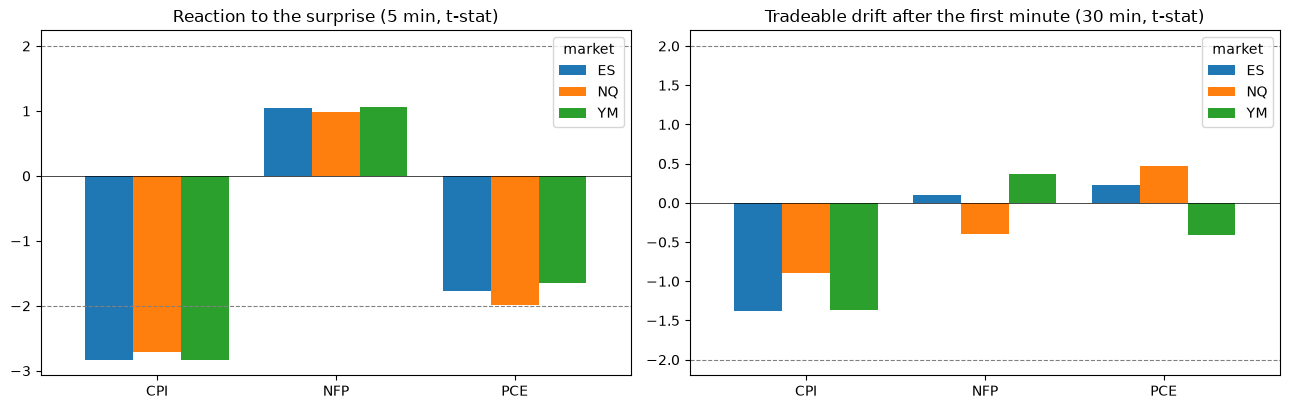

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, col, title in [(axes[0], "reaction_t_5m", "Reaction to the surprise (5 min, t-stat)"),
                       (axes[1], "drift_t_30m", "Tradeable drift after the first minute (30 min, t-stat)")]:
    summary[col].unstack("market")[list(MARKETS)].plot.bar(ax=ax, width=0.8)
    ax.axhline(2, c="gray", ls="--", lw=0.8); ax.axhline(-2, c="gray", ls="--", lw=0.8); ax.axhline(0, c="k", lw=0.5)
    ax.set_title(title); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.savefig(FIGURES_DIR / "nb02b_YM_reaction_vs_drift.png", dpi=150); plt.show()

# 8. Purpose, Research Questions, Answers, and Conclusion (YM)

## Purpose of Notebook 02b (YM)

Notebooks 01–02 showed for ES that CPI is the release whose surprise moves the market, and Notebook 02b did the same for NQ and ZN. This notebook repeats the Notebook 02 event study for the **E-mini Dow (YM)**, with ES and NQ as references, on the same 363 CPI, NFP and PCE releases (2016–2026). It asks whether YM reacts like ES, and whether part of its reaction remains after the first minute, where it can be traded.

**Data check.** 348 of 363 releases have a complete 60-minute YM window (ES 363, NQ 354), so coverage is close to the other equity markets.

### Section 4: How much does each release move YM?

**Answer:** YM moves a little less than ES and much less than NQ, with the same ranking of releases. Mean absolute 30-minute move after CPI: **YM 33.2 bps**, ES 38.5, NQ 53.6. After NFP: 27.9, 29.6 and 36.0. After PCE: 11.9, 14.9 and 18.5. Relative to its own average release, YM's profile is almost identical to ES: CPI 1.37 (ES 1.39), NFP 1.15 (ES 1.07), PCE 0.49 (ES 0.54).

### Section 5: Does the surprise explain YM's reaction?

**Answer:** Yes for CPI, as in ES. The CPI surprise explains **28% of YM's first-minute move and 27% of the 5-minute move** (ES 30% and 27%, NQ 32% and 30%). A one-standard-deviation hot headline CPI print lowers YM by **19.2 bps over 5 minutes** (t = −2.83) and 20.9 bps over 30 minutes (t = −2.54), about 92% of the ES response (−20.8 and −23.8) and 70% of NQ's (−27.7). As in ES, core CPI adds nothing once headline CPI is in the regression.

NFP is the one difference. Its surprise explains more of YM's move (R² 0.07–0.14 at 5–60 minutes) than of ES's (0.03–0.07) or NQ's (about 0.01), consistent with the Dow's tilt to industrials and banks, which gain from strong growth. No single NFP component is significant, however (|t| ≤ 1.06). PCE behaves as in ES: a small, mostly first-minute effect.

### Section 6: Is there a tradeable drift after the first minute?

**Answer:** The same weak drift as in ES. From T+1 to T+30, the headline CPI coefficient is **−5.3 bps per SD (t = −1.37)**, almost identical to ES (−5.7, t = −1.37) and NQ (−4.6, t = −0.90). Its sign is the same in 2016–2020 (−5.95, t = −1.88) and 2021–2026 (−5.54, t = −0.79). No release passes the strict rule (drift |t| > 2 with a stable sign) in YM, and none does in ES or NQ either. PCE's drift is significant in 2016–2020 (t = −2.25) but reverses sign in 2021–2026, so it is not reliable.

## Conclusion

1. **YM behaves like a slightly smaller ES.** Same releases, same signs, about 90% of ES's CPI response, and the same share of the move explained by the surprise.
2. **The CPI drift is present but, on CPI alone, not significant**, exactly as in ES and NQ. In ES and NQ the tradeable edge was established in Notebooks 04–05, which aggregate releases with walk-forward signs and test the trading P&L directly, not by this single-release regression. The same tests are needed for YM.
3. **NFP may matter more for YM than for ES and NQ**, which could change which families the screen admits in Notebook 05b.
4. **Expectation for Notebooks 03b–07b (YM):** results close to ES, and a YM book highly correlated with the ES book. YM is therefore more useful as an out-of-sample check of the ES result on a third equity index than as a source of diversification.

**Next:** Notebook 03b (YM).
